# Logistic Regression: Predicting Student Exam Success

In this example, we will use **Logistic Regression** to predict whether a student will pass an exam.

We will use three features:

- **Hours Studied** — hours studied per week
- **Attendance** — percentage of classes attended
- **Assignments Completed** — number of completed assignments

The target variable is:

- **0 → Fail**
- **1 → Pass**

The goal is to see how Logistic Regression converts several input features into a **probability of passing**, and then converts that probability into a final class prediction.

## 1. Import the Libraries

We use:

- `pandas` to organize the data
- `matplotlib` for visualization
- `LogisticRegression` from scikit-learn to build the model

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

## 2. Create the Dataset

We create a small dataset representing 20 students.

Each student has information about their study time, attendance, and completed assignments. The `Pass` column is the outcome we want the model to predict.

In [20]:
data = {
    "Hours_Studied": [
        2.5, 4.0, 5.5, 3.0, 7.0,
        6.5, 8.0, 4.5, 9.0, 5.0,
        2.0, 7.5, 6.0, 3.5, 8.5,
        4.0, 6.5, 5.5, 9.5, 3.0
    ],
    "Attendance": [
        65, 72, 81, 68, 91,
        87, 95, 76, 98, 79,
        58, 89, 84, 70, 93,
        74, 88, 80, 97, 63
    ],
    "Assignments_Completed": [
        3, 5, 7, 4, 9,
        8, 10, 6, 10, 7,
        2, 9, 8, 5, 10,
        5, 8, 7, 10, 3
    ],
    # 0 = Fail, 1 = Pass
    "Pass": [
        0, 0, 1, 0, 1,
        1, 1, 1, 1, 1,
        0, 1, 1, 0, 1,
        0, 1, 1, 1, 0
    ]
}

df = pd.DataFrame(data)

df

,Hours_Studied,Attendance,Assignments_Completed,Pass
0,2.5,65,3,0
1,4.0,72,5,0
2,5.5,81,7,1
3,3.0,68,4,0
4,7.0,91,9,1
5,6.5,87,8,1
6,8.0,95,10,1
7,4.5,76,6,1
8,9.0,98,10,1
9,5.0,79,7,1


## 3. Separate the Features and Target

The three student characteristics are our **input features**.

The `Pass` column is our **target variable**.

Conceptually:

**Hours Studied + Attendance + Assignments Completed → Logistic Regression → Probability of Passing**

In [21]:
X = df[
    ["Hours_Studied", "Attendance", "Assignments_Completed"]
]

y = df["Pass"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Hours_Studied  Attendance  Assignments_Completed
0            2.5          65                      3
1            4.0          72                      5
2            5.5          81                      7
3            3.0          68                      4
4            7.0          91                      9

Target:
0    0
1    0
2    1
3    0
4    1
Name: Pass, dtype: int64


## 4. Create and Train the Logistic Regression Model

We now create the Logistic Regression model and train it using our data.

During training, the model learns a coefficient for each feature.

Conceptually, it learns a score such as:

$$z = β₀ + β₁(Hours Studied) + β₂(Attendance) + β₃(Assignments Completed)$$

The sigmoid function then converts this score into a probability between 0 and 1.

In [22]:
model = LogisticRegression()

model.fit(X, y)

print("Model trained successfully.")

Model trained successfully.


## 5. Predict the Probability of Passing

`predict_proba()` returns the probability for each class:

- Column 0 → probability of Fail
- Column 1 → probability of Pass

We select column 1 because we are interested in the probability of passing.

In [23]:
probabilities = model.predict_proba(X)[:, 1]

df["Probability_of_Passing"] = probabilities

df[[
    "Hours_Studied",
    "Attendance",
    "Assignments_Completed",
    "Pass",
    "Probability_of_Passing"
]]

,Hours_Studied,Attendance,Assignments_Completed,Pass,Probability_of_Passing
0,2.5,65,3,0,5.498520e-05
1,4.0,72,5,0,5.342689e-02
2,5.5,81,7,1,9.969034e-01
3,3.0,68,4,0,1.096624e-03
4,7.0,91,9,1,9.999998e-01
5,6.5,87,8,1,9.999891e-01
6,8.0,95,10,1,1.000000e+00
7,4.5,76,6,1,7.265035e-01
8,9.0,98,10,1,1.000000e+00
9,5.0,79,7,1,9.814930e-01


## 6. Convert Probability into a Class

Logistic Regression gives us a probability, but we often need a final class prediction.

Using the common **0.5 threshold**:

- Probability < 0.5 → Fail (0)
- Probability ≥ 0.5 → Pass (1)

The `predict()` method performs this conversion for us.

In [24]:
predictions = model.predict(X)

df["Predicted_Class"] = predictions

df[[
    "Probability_of_Passing",
    "Predicted_Class"
]]

,Probability_of_Passing,Predicted_Class
0,5.498520e-05,0
1,5.342689e-02,0
2,9.969034e-01,1
3,1.096624e-03,0
4,9.999998e-01,1
5,9.999891e-01,1
6,1.000000e+00,1
7,7.265035e-01,1
8,1.000000e+00,1
9,9.814930e-01,1


## 7. Look at the Model's Coefficients

One advantage of Logistic Regression is that we can inspect the coefficients learned by the model.

A positive coefficient means that, all else being equal, increasing that feature increases the model's underlying score and generally increases the predicted probability of passing.

In [25]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients

,Feature,Coefficient
0,Hours_Studied,0.176799
1,Attendance,0.857519
2,Assignments_Completed,0.333014


As you can see from the table above:

- **All three features have positive coefficients**, meaning that, all else being equal, higher study hours, better attendance, and completing more assignments are associated with a higher probability of passing.

- **Attendance has the largest coefficient (≈ 0.86)**, making it the strongest contributor to the model's underlying prediction among these features.

- **Assignments Completed (≈ 0.33)** and **Hours Studied (≈ 0.18)** also contribute positively, but their coefficients are smaller than that of attendance.

## 8. Predict a New Student

Suppose a new student:

- Studies **6 hours per week**
- Has **85% attendance**
- Has completed **8 assignments**

The model first calculates a probability of passing and then uses the 0.5 threshold to produce the final prediction.

In [26]:
new_student = pd.DataFrame({
    "Hours_Studied": [6],
    "Attendance": [85],
    "Assignments_Completed": [8]
})

probability = model.predict_proba(new_student)[0, 1]
prediction = model.predict(new_student)[0]

print(f"Probability of passing: {probability:.2%}")
print(f"Prediction: {'Pass' if prediction == 1 else 'Fail'}")

Probability of passing: 99.99%
Prediction: Pass


Our model predicts that the new student has a **99.99% probability of passing the course**.

## 9. Visualize the Predicted Probabilities

Because our model uses three features, we cannot show the complete relationship in a simple 2D plot.

Instead, we can visualize the predicted probability of passing for each student.

The dashed horizontal line represents the **0.5 decision threshold**.

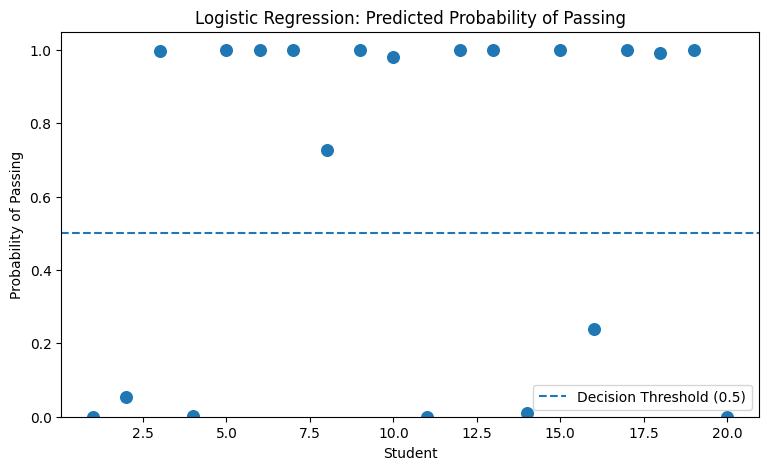

In [27]:
plt.figure(figsize=(9, 5))

student_numbers = range(1, len(df) + 1)

plt.scatter(
    student_numbers,
    df["Probability_of_Passing"],
    s=70
)

plt.axhline(
    0.5,
    linestyle="--",
    label="Decision Threshold (0.5)"
)

plt.xlabel("Student")
plt.ylabel("Probability of Passing")
plt.title("Logistic Regression: Predicted Probability of Passing")
plt.ylim(0, 1.05)
plt.legend()
plt.show()

## What Did We Learn?

The complete Logistic Regression process is:

**Student Features → Model Score → Sigmoid Function → Probability → Decision Threshold → Pass/Fail**

For a new student, the model does not directly decide "Pass" or "Fail."

It first calculates a **probability of passing**. The probability is then converted into a class using the decision threshold.

For example:

**Probability = 0.87 → 0.87 ≥ 0.50 → Pass (1)**

This is the central idea behind Logistic Regression.

> **Note:** In a real machine learning project, we would normally split the data into training and testing sets and evaluate the model on unseen data. Here, we focus on understanding how Logistic Regression produces probabilities and class predictions.